# Data Fusion: M2HATS Wind Profiler vs. ERA5

```{image} ../../thumbnails/gdex_logo.png
:alt: GDEX Cookbook logo
:width: 200px
```

---

## Overview

*Data fusion* — bringing two independent datasets onto a common grid so they can be
compared — is a routine but powerful step in geoscience. Here we compare wind
observations from a field campaign against ERA5 reanalysis.

The **M2HATS** (Multi-point Monin–Obukhov Similarity Horizontal Array Turbulence
Study) campaign collected 30-minute winds from a 449 MHz radar wind profiler. GDEX
hosts both the profiler data and co-located ERA5 (re-gridded onto height levels) as
Zarr stores in dataset [`d121499`](https://gdex.ucar.edu/datasets/d121499/).

1. Open the observation and reanalysis Zarr stores from GDEX
2. Align the profiler onto the ERA5 time grid
3. Compare wind components with scatter plots and correlation
4. Attribute the differences by day, hour, and height

:::{seealso}
Adapted from the original
[GDEX EOL–ERA5 example](https://ncar.github.io/gdex-examples/eol-era5/).
:::

## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| [xarray](https://docs.xarray.dev) | Necessary | Alignment and interpolation |
| [zarr](https://zarr.readthedocs.io) ≥ 3 | Necessary | The stores are Zarr v3 |
| [pandas](https://pandas.pydata.org) | Helpful | Grouping for the error breakdown |
| [OSDF Cookbook](https://projectpythia.org/osdf-cookbook/) | Helpful | Streaming over OSDF |

- **Time to learn**: 30 minutes

---

## Imports

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

## Loading the datasets

Dataset `d121499` holds both the 449 MHz profiler winds and ERA5 (re-gridded to
the profiler's height levels) as Zarr stores. We stream both over OSDF.

In [2]:
base = "https://osdf-director.osg-htc.org/ncar/gdex/d121499"
era5 = xr.open_zarr(f"{base}/era5_M2HATS_heights.zarr")
prof449 = xr.open_zarr(f"{base}/prof449_M2HATS_winds30.zarr")
era5

<xarray.Dataset> Size: 4MB
Dimensions:     (time: 1896, height_msl: 97)
Coordinates:
  * time        (time) datetime64[ns] 15kB 2023-07-11 ... 2023-09-27T23:00:00
  * height_msl  (height_msl) float64 776B 1.841e+03 1.941e+03 ... 1.144e+04
    longitude   float64 8B ...
    latitude    float64 8B ...
Data variables:
    v_wind      (time, height_msl) float32 736kB dask.array<chunksize=(1, 97), meta=np.ndarray>
    w_wind      (time, height_msl) float32 736kB dask.array<chunksize=(1, 97), meta=np.ndarray>
    u_wind      (time, height_msl) float32 736kB dask.array<chunksize=(1, 97), meta=np.ndarray>
    wdir        (time, height_msl) float32 736kB dask.array<chunksize=(1, 97), meta=np.ndarray>
    wspd        (time, height_msl) float32 736kB dask.array<chunksize=(1, 97), meta=np.ndarray>
Attributes:
    DATA_SOURCE:          ECMWF: https://cds.climate.copernicus.eu, Copernicu...
    NETCDF_CONVERSION:    CISL RDA: Conversion from ECMWF GRIB 1 data to netC...
    NETCDF_VERSION:       4.8.1
    CONVERSION_PLATFORM:  Linux r2i4n28 4.12.14-95.51-default #1 SMP Fri Apr ...
    CONVERSION_DATE:      Fri Oct  6 09:19:55 MDT 2023
    Conventions:          CF-1.6
    NETCDF_COMPRESSION:   NCO: Precision-preserving compression to netCDF4/HD...
    history:              Fri Oct  6 09:20:11 2023: ncks -4 --ppc default=7 e...
    NCO:                  netCDF Operators version 5.0.3 (Homepage = http://n...

## Aligning the datasets

The profiler reports every 30 minutes while ERA5 is hourly. Interpolating the
profiler onto the ERA5 time grid puts both on identical time and height coordinates
— the step that makes a point-by-point comparison meaningful.

In [3]:
prof449 = prof449.interp(time=era5["time"])

## Comparing wind components

We scatter each profiler wind component against ERA5 over the whole campaign. Points
near the `x = y` line indicate agreement; `r` and `R²` quantify it.

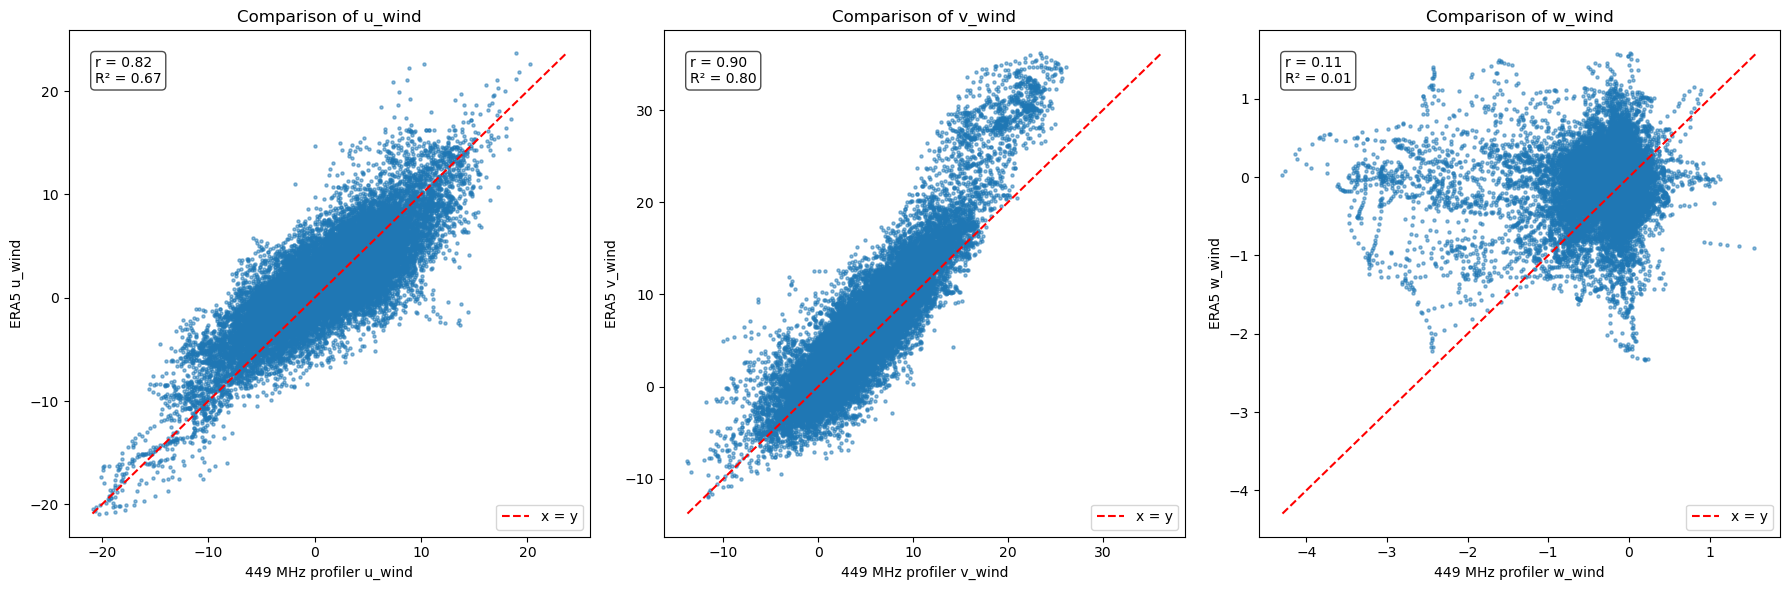

In [4]:
vars_to_compare = ["u_wind", "v_wind", "w_wind"]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, var in zip(axes, vars_to_compare):
    x = prof449[var].values.ravel()
    y = era5[var].values.ravel()
    mask = ~np.isnan(x) & ~np.isnan(y)
    x, y = x[mask], y[mask]

    ax.scatter(x, y, s=5, alpha=0.5)
    lims = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(lims, lims, "r--", label="x = y")

    r = np.corrcoef(x, y)[0, 1]
    ax.text(0.05, 0.95, f"r = {r:.2f}\nR² = {r**2:.2f}", transform=ax.transAxes,
            va="top", ha="left", bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))
    ax.set_xlabel(f"449 MHz profiler {var}")
    ax.set_ylabel(f"ERA5 {var}")
    ax.set_title(f"Comparison of {var}")
    ax.legend()

plt.tight_layout()
plt.show()

The horizontal components (`u_wind`, `v_wind`) track the `x = y` line closely with
high `R²` — ERA5 represents them well. The vertical wind (`w_wind`) scatters far more,
a known limitation of reanalysis for small-scale vertical motion.

## Attributing the differences

Where do the two diverge? We break the mean absolute error (MAE) down by day, hour
of day, and height — for wind speed, direction, and vertical wind. Wind direction
uses a circular difference so the 0°/360° wrap doesn't inflate the error.

/tmp/ipykernel_403/396819726.py:23: RuntimeWarning: Mean of empty slice
  mae_height = np.nanmean(error, axis=0)
/tmp/ipykernel_403/396819726.py:23: RuntimeWarning: Mean of empty slice
  mae_height = np.nanmean(error, axis=0)
/tmp/ipykernel_403/396819726.py:23: RuntimeWarning: Mean of empty slice
  mae_height = np.nanmean(error, axis=0)


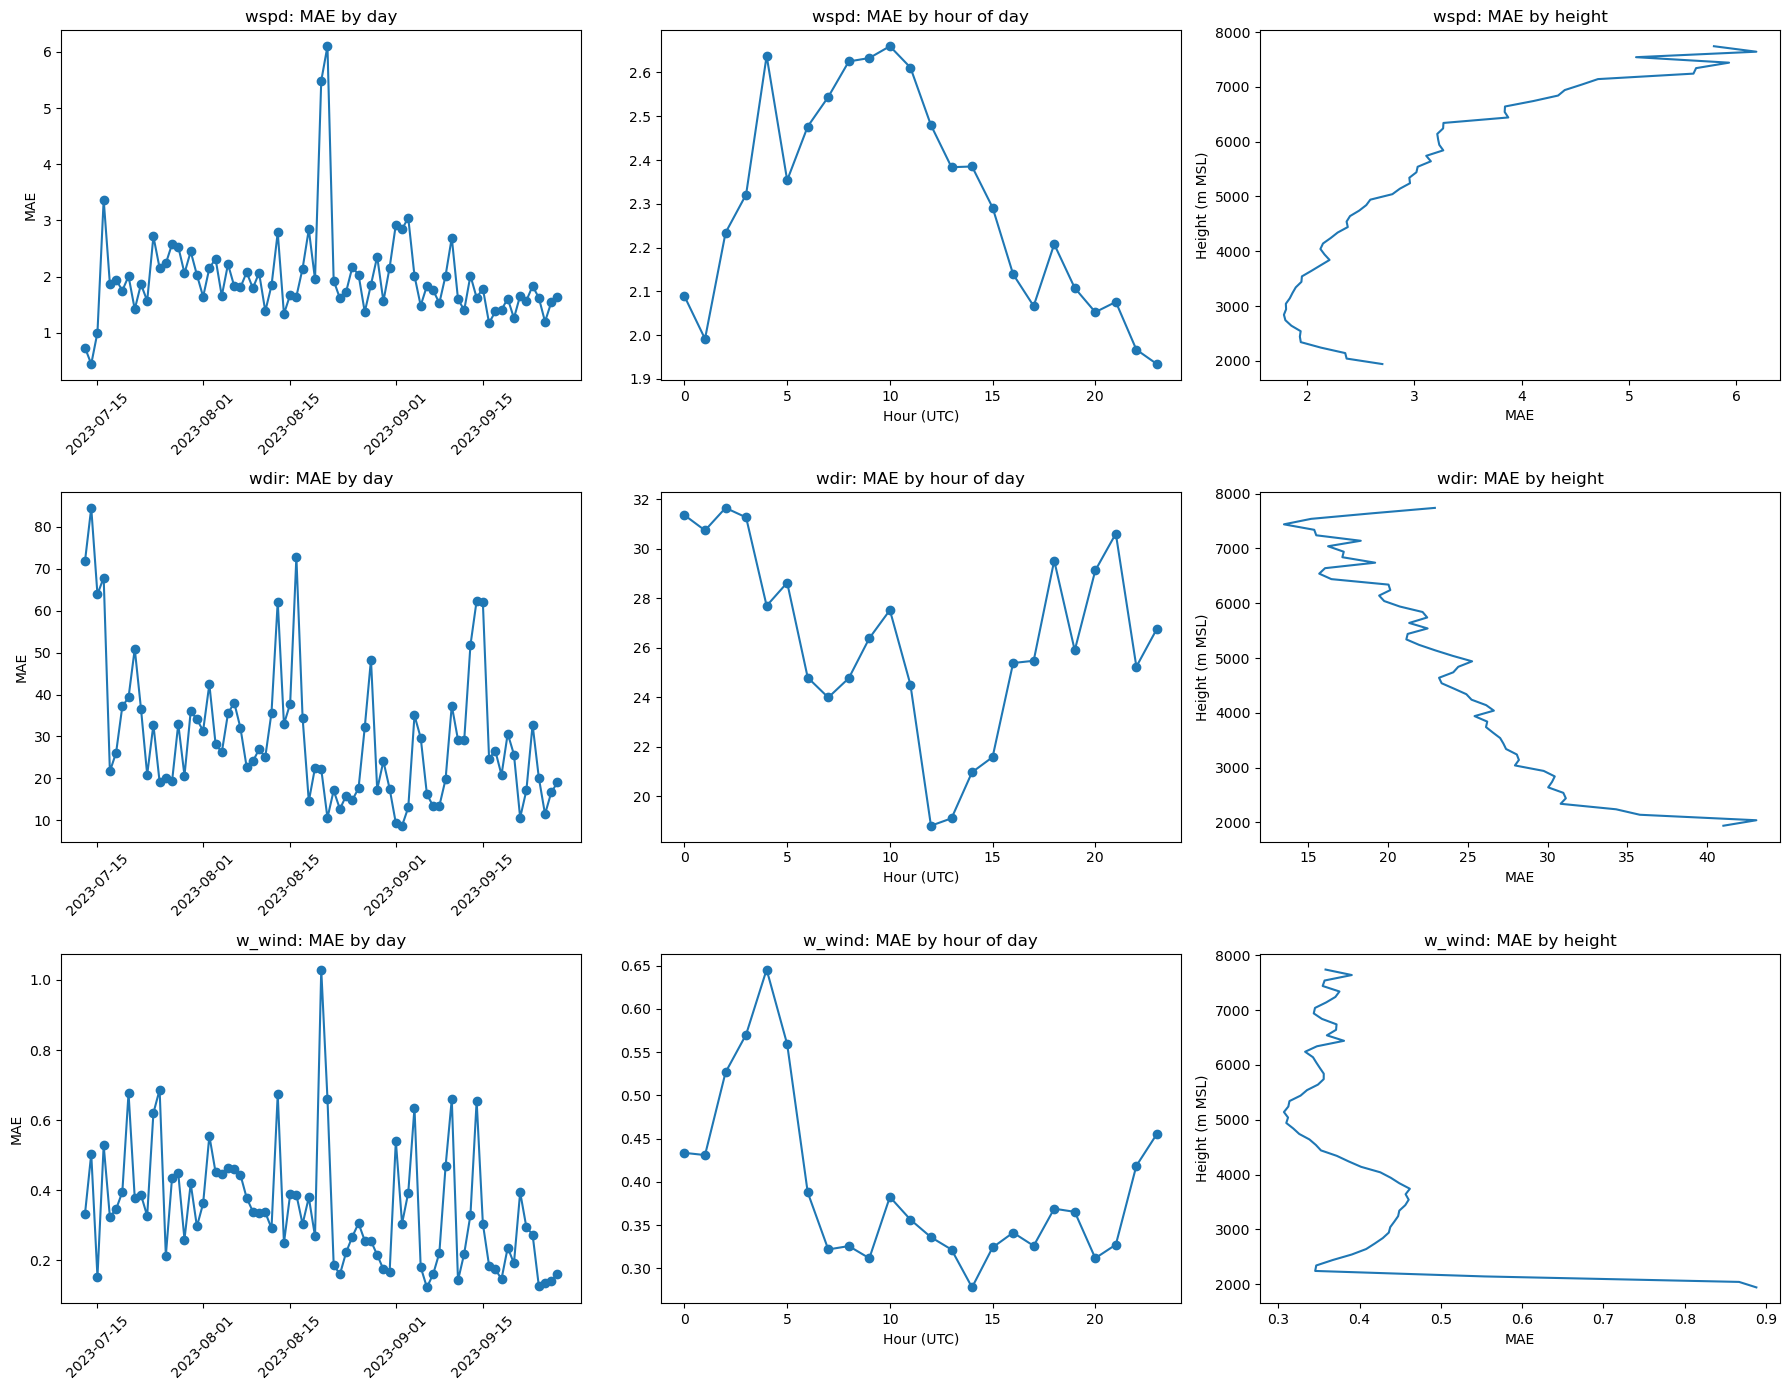

In [5]:
vars_to_compare = ["wspd", "wdir", "w_wind"]
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 14))

for row, var in enumerate(vars_to_compare):
    obs = prof449[var].values
    mod = era5[var].values
    time = prof449["time"].values
    height = prof449["height_msl"].values

    if var == "wdir":
        error = np.abs((obs - mod + 180) % 360 - 180)
    else:
        error = np.abs(obs - mod)

    df = pd.DataFrame({
        "time": np.repeat(time, len(height)),
        "error": error.reshape(len(time) * len(height)),
    })
    df["day"] = pd.to_datetime(df["time"]).dt.date
    df["hour"] = pd.to_datetime(df["time"]).dt.hour
    mae_daily = df.groupby("day")["error"].mean()
    mae_hourly = df.groupby("hour")["error"].mean()
    mae_height = np.nanmean(error, axis=0)

    axes[row, 0].plot(mae_daily.index, mae_daily.values, marker="o")
    axes[row, 0].set_title(f"{var}: MAE by day")
    axes[row, 0].set_ylabel("MAE")
    axes[row, 0].tick_params(axis="x", rotation=45)

    axes[row, 1].plot(mae_hourly.index, mae_hourly.values, marker="o")
    axes[row, 1].set_title(f"{var}: MAE by hour of day")
    axes[row, 1].set_xlabel("Hour (UTC)")

    axes[row, 2].plot(mae_height, height)
    axes[row, 2].set_title(f"{var}: MAE by height")
    axes[row, 2].set_xlabel("MAE")
    axes[row, 2].set_ylabel("Height (m MSL)")

plt.tight_layout()
plt.show()

The breakdown localizes the disagreement: wind-speed MAE spikes on 20–21 Aug 2023,
coinciding with the passage of Tropical Storm Hilary; there's a diurnal signal by
hour; and error grows with height. This is exactly the payoff of fusing the two
datasets — the comparison points to *when* and *where* to look closer.

---

## Summary

We fused two GDEX datasets — 449 MHz profiler observations and ERA5 reanalysis —
from a single campaign dataset, aligned them onto a common time/height grid, and
compared wind components with scatter plots and an MAE breakdown by day, hour, and
height. The same recipe (open → align → compare → attribute) generalizes to any
obs-vs-model or model-vs-model comparison on GDEX.

### What's next?

This rounds out the workflow series. Feel free to open a pull request and contribute a new workflow!

## Resources and references

- [GDEX M2HATS / ERA5 dataset (`d121499`)](https://gdex.ucar.edu/datasets/d121499/)
- [Original GDEX EOL–ERA5 example](https://ncar.github.io/gdex-examples/eol-era5/)
- [M2HATS field campaign (NCAR EOL)](https://www.eol.ucar.edu/field_projects/m2hats)
- [ERA5 documentation (ECMWF)](https://confluence.ecmwf.int/display/CKB/ERA5)
- [xarray documentation](https://docs.xarray.dev)